In [1]:
# ============================================================
# Results Notebook — Path Setup
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

# Recommended when the notebook is inside a notebooks/ folder:
# project_root/
#   notebooks/
#       results_tables_figures.ipynb
#   outputs/
#       data_audit/
#       feature_definition/
#       primary_statistics/
#       candidate_scorecard/
#       ...

PROJECT_ROOT = Path.cwd().parent

# Pipeline output directory
PIPELINE_OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Notebook-generated manuscript outputs
RESULTS_OUTPUT_DIR = PROJECT_ROOT / "results_outputs"
TABLE_DIR = RESULTS_OUTPUT_DIR / "tables"
FIGURE_DIR = RESULTS_OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Pipeline outputs:", PIPELINE_OUTPUT_DIR)
print("Notebook result outputs:", RESULTS_OUTPUT_DIR)

Project root: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI
Pipeline outputs: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs
Notebook result outputs: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/results_outputs


In [2]:
# ============================================================
# Input CSV paths used across Results subsections
# ============================================================

# -----------------------------
# Cohort and ECG segment overview
# -----------------------------
data_integrity_path = (
    PIPELINE_OUTPUT_DIR / "data_audit" / "data_integrity_summary.csv"
)

segment_counts_path = (
    PIPELINE_OUTPUT_DIR / "data_audit" / "segment_counts_by_patient_condition.csv"
)

informative_feature_summary_path = (
    PIPELINE_OUTPUT_DIR / "feature_definition" / "informative_feature_summary.csv"
)

cohort_description_path = (
    PIPELINE_OUTPUT_DIR / "clinical_metadata" / "cohort_description_table.csv"
)

qc_exclusion_counts_path = (
    PIPELINE_OUTPUT_DIR / "segment_qc" / "qc_exclusion_counts.csv"
)

# -----------------------------
# Primary patient-level paired analysis
# -----------------------------
primary_paired_fdr_path = (
    PIPELINE_OUTPUT_DIR / "primary_statistics" / 
    "primary_paired_feature_results_all_features_fdr.csv"
)

fdr_summary_by_family_path = (
    PIPELINE_OUTPUT_DIR / "primary_statistics" / "fdr_summary_by_family.csv"
)

patient_feature_delta_path = (
    PIPELINE_OUTPUT_DIR / "patient_level" / 
    "patient_feature_delta_table_all_features.csv"
)

# -----------------------------
# Candidate scorecard
# -----------------------------
final_candidate_scorecard_path = (
    PIPELINE_OUTPUT_DIR / "candidate_scorecard" / "final_candidate_scorecard.csv"
)

final_candidate_categories_path = (
    PIPELINE_OUTPUT_DIR / "candidate_scorecard" / 
    "final_candidate_feature_categories.csv"
)

preliminary_priority_path = (
    PIPELINE_OUTPUT_DIR / "candidate_scorecard" / 
    "preliminary_feature_priority_table.csv"
)

preliminary_shortlist_path = (
    PIPELINE_OUTPUT_DIR / "candidate_scorecard" / 
    "preliminary_candidate_shortlist.csv"
)

# -----------------------------
# HRV-valid subgroup
# -----------------------------
hrv_valid_results_path = (
    PIPELINE_OUTPUT_DIR / "hrv_subgroup" / "hrv_valid_feature_results.csv"
)

hrv_valid_inclusion_path = (
    PIPELINE_OUTPUT_DIR / "hrv_subgroup" / 
    "hrv_valid_patient_inclusion_table.csv"
)

# -----------------------------
# Supportive mixed-effects models
# -----------------------------
lmm_results_path = (
    PIPELINE_OUTPUT_DIR / "mixed_effects" / 
    "lmm_supportive_results_all_features.csv"
)

# -----------------------------
# Sensitivity and robustness
# -----------------------------
sensitivity_summary_path = (
    PIPELINE_OUTPUT_DIR / "sensitivity" / 
    "sensitivity_vs_full_cohort_summary.csv"
)

robustness_matrix_path = (
    PIPELINE_OUTPUT_DIR / "sensitivity" / 
    "candidate_feature_robustness_matrix.csv"
)

# -----------------------------
# Patient-level agreement/disagreement
# -----------------------------
patient_disagreement_summary_path = (
    PIPELINE_OUTPUT_DIR / "agreement_disagreement" / 
    "patient_disagreement_summary.csv"
)

feature_agreement_summary_path = (
    PIPELINE_OUTPUT_DIR / "agreement_disagreement" / 
    "feature_agreement_summary.csv"
)

In [3]:
# ============================================================
# Check that required files exist
# ============================================================

required_paths = {
    "data_integrity": data_integrity_path,
    "segment_counts": segment_counts_path,
    "informative_feature_summary": informative_feature_summary_path,
    "cohort_description": cohort_description_path,
    "qc_exclusion_counts": qc_exclusion_counts_path,
    "primary_paired_fdr": primary_paired_fdr_path,
    "fdr_summary_by_family": fdr_summary_by_family_path,
    "patient_feature_delta": patient_feature_delta_path,
    "final_candidate_scorecard": final_candidate_scorecard_path,
    "final_candidate_categories": final_candidate_categories_path,
    "hrv_valid_results": hrv_valid_results_path,
    "hrv_valid_inclusion": hrv_valid_inclusion_path,
    "lmm_results": lmm_results_path,
    "sensitivity_summary": sensitivity_summary_path,
    "robustness_matrix": robustness_matrix_path,
    "patient_disagreement_summary": patient_disagreement_summary_path,
    "feature_agreement_summary": feature_agreement_summary_path,
}

missing_files = []

for name, path in required_paths.items():
    if not path.exists():
        missing_files.append((name, path))

if missing_files:
    print("Missing files:")
    for name, path in missing_files:
        print(f"  - {name}: {path}")
else:
    print("All required files found.")

All required files found.


In [4]:
# ============================================================
# Shared IEEE-style figure settings
# ============================================================

IEEE_STYLE = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

plt.rcParams.update(IEEE_STYLE)

# Okabe-Ito colorblind-safe palette
COLORS = {
    "prehi": "#0072B2",      # blue
    "hi": "#E69F00",         # orange
    "increase": "#009E73",   # green
    "decrease": "#D55E00",   # vermillion
    "neutral": "#999999",    # grey
    "highlight": "#CC79A7",  # purple
}

# IEEE Access double-column width is approximately 7.16 inches
FIG_WIDTH_FULL = 7.16
FIG_WIDTH_SINGLE = 3.45

In [5]:
# ============================================================
# Primary Patient-Level Paired Analysis Across ECG Features
# Load source CSVs
# ============================================================

primary_fdr = pd.read_csv(primary_paired_fdr_path)
fdr_family = pd.read_csv(fdr_summary_by_family_path)

print("primary_fdr:", primary_fdr.shape)
print("fdr_family:", fdr_family.shape)

display(primary_fdr.head())
display(fdr_family.head())

primary_fdr: (52, 25)
fdr_family: (7, 8)


,feature,feature_family,n_paired_patients,median_PreHI,median_HI,median_delta_HI_minus_PreHI,median_percent_change,n_increase,n_decrease,n_no_change,...,bootstrap_median_delta_ci_high,bootstrap_ci_excludes_zero,n_percent_change_unstable,abs_rank_biserial_effect_size,wilcoxon_p_fdr_global,wilcoxon_p_fdr_family,global_fdr_significant,family_fdr_significant,raw_p_less_0_05,candidate_support_tier_preliminary
0,QRS_mean,ECG morphology and signal energy,20,0.134478,0.151313,0.010358,5.902620,12,8,0,...,0.029739,0,0,0.571429,0.433006,0.119753,0,0,1,exploratory
1,HRV_pNN50,HRV,20,44.738295,30.966069,-11.345795,-21.293145,7,13,0,...,0.770115,0,0,0.561905,0.433006,0.106339,0,0,1,exploratory
2,entropyProfiled_maximum_sampleEntropy,entropy-profile aggregate features,20,2.382500,2.342500,-0.255000,-14.036859,5,13,2,...,0.000000,0,0,0.567251,0.433006,0.277360,0,0,1,exploratory
3,kurtosis,time-domain statistics,20,5.980000,5.885000,0.992500,24.686602,15,5,0,...,1.965000,1,0,0.533333,0.433006,0.362339,0,0,1,raw_p_effect_direction_supported
4,HRV_MeanNN,HRV,20,626.025792,642.407174,20.759494,3.971999,15,5,0,...,67.209649,1,0,0.495238,0.433006,0.106339,0,0,0,exploratory


,feature_family,n_features,n_raw_p_less_0_05,n_global_fdr_significant,n_family_fdr_significant,min_raw_p,min_global_fdr_p,min_family_fdr_p
0,ECG morphology and signal energy,5,1,0,0,0.023951,0.433006,0.119753
1,HRV,4,1,0,0,0.026642,0.433006,0.106339
2,entropy-profile aggregate features,8,1,0,0,0.034670,0.433006,0.277360
3,time-domain statistics,10,1,0,0,0.036234,0.433006,0.362339
4,entropy and complexity,10,0,0,0,0.063996,0.433006,0.311622


In [6]:
# ============================================================
# Helper functions for manuscript formatting
# ============================================================

def format_p_value(p):
    """Format p-values for manuscript tables."""
    if pd.isna(p):
        return ""
    p = float(p)
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"


def format_float(x, digits=3):
    """Format numeric values with fixed decimal places."""
    if pd.isna(x):
        return ""
    return f"{float(x):.{digits}f}"


def format_delta(x):
    """Format median paired difference with sign."""
    if pd.isna(x):
        return ""
    return f"{float(x):+.4g}"


def direction_label(direction):
    """Convert pipeline direction labels to manuscript-friendly labels."""
    mapping = {
        "increase": "Increased",
        "decrease": "Decreased",
        "no_change": "No change",
        "tie_or_mixed": "Mixed",
        "missing": "Missing"
    }
    return mapping.get(str(direction), str(direction))


def shorten_family_name(family):
    """Compact family names for tables/figures."""
    mapping = {
        "ECG morphology and signal energy": "Morphology/signal energy",
        "entropy-profile aggregate features": "Entropy-profile",
        "fractal-dimension summary features": "Fractal dimension",
        "entropy and complexity": "Entropy/complexity",
        "fractal and nonlinear dynamics": "Fractal/nonlinear",
        "time-domain statistics": "Time-domain",
        "spectral features": "Spectral",
        "HRV": "HRV",
        "unknown/unmapped": "Unmapped"
    }
    return mapping.get(str(family), str(family))

In [7]:
# ============================================================
# Table II-A — Overall primary paired analysis summary
# ============================================================

n_features_tested = int(primary_fdr["feature"].nunique())
n_raw_p_005 = int((primary_fdr["wilcoxon_p"] < 0.05).sum())
n_global_fdr_sig = int(primary_fdr["global_fdr_significant"].sum())
n_family_fdr_sig = int(primary_fdr["family_fdr_significant"].sum())
n_bootstrap_excludes_zero = int(primary_fdr["bootstrap_ci_excludes_zero"].sum())

min_raw_p = primary_fdr["wilcoxon_p"].min()
min_global_fdr_p = primary_fdr["wilcoxon_p_fdr_global"].min()
min_family_fdr_p = primary_fdr["wilcoxon_p_fdr_family"].min()

primary_summary_table = pd.DataFrame({
    "Analysis summary": [
        "Informative ECG-derived features tested",
        "Features with uncorrected Wilcoxon p < 0.05",
        "Features significant after global FDR correction",
        "Features significant after family-level FDR correction",
        "Features with bootstrap median-delta CI excluding zero",
        "Minimum uncorrected Wilcoxon p",
        "Minimum global FDR-adjusted p",
        "Minimum family FDR-adjusted p",
    ],
    "Value": [
        n_features_tested,
        n_raw_p_005,
        n_global_fdr_sig,
        n_family_fdr_sig,
        n_bootstrap_excludes_zero,
        format_p_value(min_raw_p),
        format_p_value(min_global_fdr_p),
        format_p_value(min_family_fdr_p),
    ]
})

display(primary_summary_table)

primary_summary_table.to_csv(
    TABLE_DIR / "table_primary_paired_overall_summary.csv",
    index=False
)

latex_primary_summary = primary_summary_table.to_latex(
    index=False,
    escape=False,
    column_format="p{0.68\\linewidth}p{0.22\\linewidth}",
    caption=(
        "Primary Patient-Level Paired Analysis Summary. "
        "FDR correction was applied globally across all informative features and separately within feature families."
    ),
    label="tab:primary_paired_overall_summary"
)

with open(TABLE_DIR / "table_primary_paired_overall_summary.tex", "w") as f:
    f.write(latex_primary_summary)

print(latex_primary_summary)

,Analysis summary,Value
0,Informative ECG-derived features tested,52
1,Features with uncorrected Wilcoxon p < 0.05,4
2,Features significant after global FDR correction,0
3,Features significant after family-level FDR co...,0
4,Features with bootstrap median-delta CI exclud...,2
5,Minimum uncorrected Wilcoxon p,0.024
6,Minimum global FDR-adjusted p,0.433
7,Minimum family FDR-adjusted p,0.106


\begin{table}
\caption{Primary Patient-Level Paired Analysis Summary. FDR correction was applied globally across all informative features and separately within feature families.}
\label{tab:primary_paired_overall_summary}
\begin{tabular}{p{0.68\linewidth}p{0.22\linewidth}}
\toprule
Analysis summary & Value \\
\midrule
Informative ECG-derived features tested & 52 \\
Features with uncorrected Wilcoxon p < 0.05 & 4 \\
Features significant after global FDR correction & 0 \\
Features significant after family-level FDR correction & 0 \\
Features with bootstrap median-delta CI excluding zero & 2 \\
Minimum uncorrected Wilcoxon p & 0.024 \\
Minimum global FDR-adjusted p & 0.433 \\
Minimum family FDR-adjusted p & 0.106 \\
\bottomrule
\end{tabular}
\end{table}



In [8]:
# ============================================================
# Table II-B — Screening-level features with raw Wilcoxon p < 0.05
# This is useful for the main manuscript.
# ============================================================

screening_features = (
    primary_fdr[primary_fdr["wilcoxon_p"] < 0.05]
    .copy()
    .sort_values("wilcoxon_p", ascending=True)
)

screening_table = pd.DataFrame({
    "Feature": screening_features["feature"],
    "Family": screening_features["feature_family"].map(shorten_family_name),
    "Direction during HI": screening_features["dominant_direction"].map(direction_label),
    "Median $\\Delta$": screening_features["median_delta_HI_minus_PreHI"].map(format_delta),
    "Direction consistency": screening_features["direction_consistency"].map(lambda x: format_float(x, 2)),
    "Rank-biserial effect": screening_features["rank_biserial_effect_size"].map(lambda x: format_float(x, 3)),
    "Wilcoxon $p$": screening_features["wilcoxon_p"].map(format_p_value),
    "Global FDR $p$": screening_features["wilcoxon_p_fdr_global"].map(format_p_value),
    "Family FDR $p$": screening_features["wilcoxon_p_fdr_family"].map(format_p_value),
})

display(screening_table)

screening_table.to_csv(
    TABLE_DIR / "table_primary_paired_screening_level_features.csv",
    index=False
)

latex_screening_table = screening_table.to_latex(
    index=False,
    escape=False,
    column_format="p{0.21\\linewidth}p{0.17\\linewidth}p{0.12\\linewidth}rrrrrr",
    caption=(
        "Screening-Level Features From the Primary Patient-Level Paired Analysis. "
        "Rows show features with uncorrected Wilcoxon $p<0.05$. "
        "None survived global or family-level FDR correction."
    ),
    label="tab:primary_paired_screening_features"
)

with open(TABLE_DIR / "table_primary_paired_screening_level_features.tex", "w") as f:
    f.write(latex_screening_table)

print(latex_screening_table)

,Feature,Family,Direction during HI,Median $\Delta$,Direction consistency,Rank-biserial effect,Wilcoxon $p$,Global FDR $p$,Family FDR $p$
0,QRS_mean,Morphology/signal energy,Increased,+0.01036,0.60,0.571,0.024,0.433,0.120
1,HRV_pNN50,HRV,Decreased,-11.35,0.65,-0.562,0.027,0.433,0.106
2,entropyProfiled_maximum_sampleEntropy,Entropy-profile,Decreased,-0.255,0.65,-0.567,0.035,0.433,0.277
3,kurtosis,Time-domain,Increased,+0.9925,0.75,0.533,0.036,0.433,0.362


\begin{table}
\caption{Screening-Level Features From the Primary Patient-Level Paired Analysis. Rows show features with uncorrected Wilcoxon $p<0.05$. None survived global or family-level FDR correction.}
\label{tab:primary_paired_screening_features}
\begin{tabular}{p{0.21\linewidth}p{0.17\linewidth}p{0.12\linewidth}rrrrrr}
\toprule
Feature & Family & Direction during HI & Median $\Delta$ & Direction consistency & Rank-biserial effect & Wilcoxon $p$ & Global FDR $p$ & Family FDR $p$ \\
\midrule
QRS_mean & Morphology/signal energy & Increased & +0.01036 & 0.60 & 0.571 & 0.024 & 0.433 & 0.120 \\
HRV_pNN50 & HRV & Decreased & -11.35 & 0.65 & -0.562 & 0.027 & 0.433 & 0.106 \\
entropyProfiled_maximum_sampleEntropy & Entropy-profile & Decreased & -0.255 & 0.65 & -0.567 & 0.035 & 0.433 & 0.277 \\
kurtosis & Time-domain & Increased & +0.9925 & 0.75 & 0.533 & 0.036 & 0.433 & 0.362 \\
\bottomrule
\end{tabular}
\end{table}



In [9]:
# ============================================================
# Table II-C — FDR summary by feature family
# Best suited for Supplementary Material, but useful to generate.
# ============================================================

fdr_family_table = fdr_family.copy()

fdr_family_table["Feature family"] = fdr_family_table["feature_family"].map(shorten_family_name)
fdr_family_table["Features tested"] = fdr_family_table["n_features"].astype(int)
fdr_family_table["Raw p < 0.05"] = fdr_family_table["n_raw_p_less_0_05"].astype(int)
fdr_family_table["Global FDR sig."] = fdr_family_table["n_global_fdr_significant"].astype(int)
fdr_family_table["Family FDR sig."] = fdr_family_table["n_family_fdr_significant"].astype(int)
fdr_family_table["Minimum raw p"] = fdr_family_table["min_raw_p"].map(format_p_value)
fdr_family_table["Minimum family FDR p"] = fdr_family_table["min_family_fdr_p"].map(format_p_value)

fdr_family_table = fdr_family_table[
    [
        "Feature family",
        "Features tested",
        "Raw p < 0.05",
        "Global FDR sig.",
        "Family FDR sig.",
        "Minimum raw p",
        "Minimum family FDR p",
    ]
].sort_values("Minimum raw p")

display(fdr_family_table)

fdr_family_table.to_csv(
    TABLE_DIR / "table_fdr_summary_by_feature_family.csv",
    index=False
)

latex_fdr_family_table = fdr_family_table.to_latex(
    index=False,
    escape=False,
    column_format="p{0.30\\linewidth}rrrrrr",
    caption=(
        "Feature-Family Summary of Primary Patient-Level Paired Testing. "
        "No feature family contained a feature that survived family-level FDR correction."
    ),
    label="tab:fdr_summary_by_feature_family"
)

with open(TABLE_DIR / "table_fdr_summary_by_feature_family.tex", "w") as f:
    f.write(latex_fdr_family_table)

print(latex_fdr_family_table)

,Feature family,Features tested,Raw p < 0.05,Global FDR sig.,Family FDR sig.,Minimum raw p,Minimum family FDR p
0,Morphology/signal energy,5,1,0,0,0.024,0.120
1,HRV,4,1,0,0,0.027,0.106
2,Entropy-profile,8,1,0,0,0.035,0.277
3,Time-domain,10,1,0,0,0.036,0.362
4,Entropy/complexity,10,0,0,0,0.064,0.312
5,Fractal dimension,9,0,0,0,0.067,0.342
6,Fractal/nonlinear,6,0,0,0,0.191,0.759


\begin{table}
\caption{Feature-Family Summary of Primary Patient-Level Paired Testing. No feature family contained a feature that survived family-level FDR correction.}
\label{tab:fdr_summary_by_feature_family}
\begin{tabular}{p{0.30\linewidth}rrrrrr}
\toprule
Feature family & Features tested & Raw p < 0.05 & Global FDR sig. & Family FDR sig. & Minimum raw p & Minimum family FDR p \\
\midrule
Morphology/signal energy & 5 & 1 & 0 & 0 & 0.024 & 0.120 \\
HRV & 4 & 1 & 0 & 0 & 0.027 & 0.106 \\
Entropy-profile & 8 & 1 & 0 & 0 & 0.035 & 0.277 \\
Time-domain & 10 & 1 & 0 & 0 & 0.036 & 0.362 \\
Entropy/complexity & 10 & 0 & 0 & 0 & 0.064 & 0.312 \\
Fractal dimension & 9 & 0 & 0 & 0 & 0.067 & 0.342 \\
Fractal/nonlinear & 6 & 0 & 0 & 0 & 0.191 & 0.759 \\
\bottomrule
\end{tabular}
\end{table}



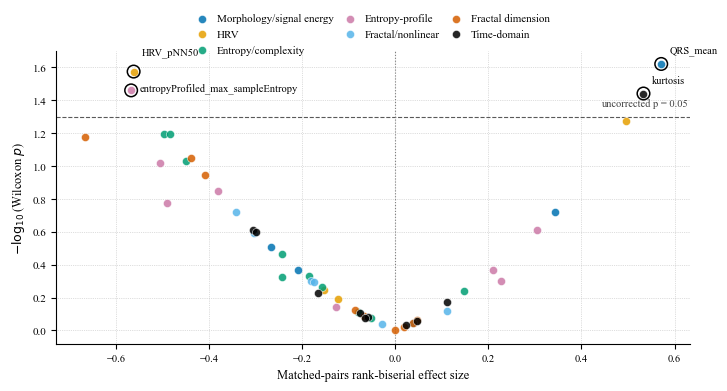

In [10]:
# ============================================================
# Figure 2 — Primary feature evidence landscape
# Refined label placement
# ============================================================

evidence_df = primary_fdr.copy()

# Safe -log10 p
evidence_df["wilcoxon_p_safe"] = pd.to_numeric(
    evidence_df["wilcoxon_p"],
    errors="coerce"
).clip(lower=1e-300)

evidence_df["neg_log10_p"] = -np.log10(evidence_df["wilcoxon_p_safe"])

# Mark raw p < 0.05
evidence_df["raw_p_lt_0_05"] = evidence_df["wilcoxon_p"] < 0.05

# Family colors
families = sorted(evidence_df["feature_family"].dropna().unique())

family_color_map = {
    "ECG morphology and signal energy": "#0072B2",
    "HRV": "#E69F00",
    "entropy-profile aggregate features": "#CC79A7",
    "entropy and complexity": "#009E73",
    "fractal-dimension summary features": "#D55E00",
    "fractal and nonlinear dynamics": "#56B4E9",
    "time-domain statistics": "#000000",
    "spectral features": "#F0E442",
    "unknown/unmapped": "#999999",
}

default_color = "#999999"

fig, ax = plt.subplots(
    figsize=(FIG_WIDTH_FULL, 3.8),
    constrained_layout=True
)

# Plot all features by family
for family in families:
    sub = evidence_df[evidence_df["feature_family"] == family]
    ax.scatter(
        sub["rank_biserial_effect_size"],
        sub["neg_log10_p"],
        s=34,
        alpha=0.85,
        color=family_color_map.get(family, default_color),
        edgecolor="white",
        linewidth=0.4,
        label=shorten_family_name(family),
        zorder=3,
    )

# Highlight raw p < 0.05 features
highlight = evidence_df[evidence_df["raw_p_lt_0_05"]].copy()

ax.scatter(
    highlight["rank_biserial_effect_size"],
    highlight["neg_log10_p"],
    s=82,
    facecolors="none",
    edgecolors="black",
    linewidth=1.1,
    zorder=4,
)

# Shorter display labels for figure only
display_label_map = {
    "QRS_mean": "QRS_mean",
    "kurtosis": "kurtosis",
    "HRV_pNN50": "HRV_pNN50",
    "entropyProfiled_maximum_sampleEntropy": "entropyProfiled_max_sampleEntropy",
}

# Manual label offsets (in points) for cleaner placement
label_offsets = {
    "HRV_pNN50": (6, 10),
    "entropyProfiled_maximum_sampleEntropy": (6, -2),
    "kurtosis": (6, 6),
    "QRS_mean": (6, 6),
}

# Label raw p < 0.05 features with manual offsets
for _, row in highlight.iterrows():
    feature_name = row["feature"]
    label_text = display_label_map.get(feature_name, feature_name)
    dx, dy = label_offsets.get(feature_name, (5, 5))

    ax.annotate(
        label_text,
        xy=(row["rank_biserial_effect_size"], row["neg_log10_p"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7.5,
        ha="left",
        va="bottom",
    )

# Reference lines
raw_p_threshold = -np.log10(0.05)

ax.axhline(
    raw_p_threshold,
    color="0.35",
    linestyle="--",
    linewidth=0.8,
    zorder=2,
)

ax.axvline(
    0,
    color="0.5",
    linestyle=":",
    linewidth=0.8,
    zorder=2,
)

# Move threshold annotation slightly left/up for less crowding
ax.text(
    0.86,
    raw_p_threshold + 0.05,
    "uncorrected p = 0.05",
    transform=ax.get_yaxis_transform(),
    ha="left",
    va="bottom",
    fontsize=7.5,
    color="0.25",
)

ax.set_xlabel("Matched-pairs rank-biserial effect size")
ax.set_ylabel(r"$-\log_{10}$(Wilcoxon $p$)")

ax.grid(
    axis="both",
    linestyle=":",
    linewidth=0.5,
    color="0.75",
    zorder=0,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Compact legend
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=3,
    handlelength=1.0,
    columnspacing=1.0,
)

# Save figure
fig.savefig(
    FIGURE_DIR / "figure2_primary_feature_evidence_landscape.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIGURE_DIR / "figure2_primary_feature_evidence_landscape.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# Optional LaTeX figure block for IEEE Access
# ============================================================

latex_figure2 = r"""
\begin{figure*}[t]
    \centering
    \includegraphics[width=\textwidth]{figures/figure2_primary_feature_evidence_landscape.pdf}
    \caption{Primary patient-level paired evidence across 52 informative ECG-derived features. Each point represents one feature tested using paired Pre-HI and During-HI patient-level medians. The x-axis shows the matched-pairs rank-biserial effect size, where positive values indicate higher feature values during HI and negative values indicate lower feature values during HI. The y-axis shows $-\log_{10}$ of the uncorrected Wilcoxon signed-rank $p$-value. The dashed line marks the uncorrected $p=0.05$ threshold. Circled and labelled features reached uncorrected $p<0.05$, but no feature survived global or family-level FDR correction.}
    \label{fig:primary_feature_evidence_landscape}
\end{figure*}
"""

with open(TABLE_DIR / "latex_figure2_primary_feature_evidence_landscape.tex", "w") as f:
    f.write(latex_figure2)

print(latex_figure2)


\begin{figure*}[t]
    \centering
    \includegraphics[width=\textwidth]{figures/figure2_primary_feature_evidence_landscape.pdf}
    \caption{Primary patient-level paired evidence across 52 informative ECG-derived features. Each point represents one feature tested using paired Pre-HI and During-HI patient-level medians. The x-axis shows the matched-pairs rank-biserial effect size, where positive values indicate higher feature values during HI and negative values indicate lower feature values during HI. The y-axis shows $-\log_{10}$ of the uncorrected Wilcoxon signed-rank $p$-value. The dashed line marks the uncorrected $p=0.05$ threshold. Circled and labelled features reached uncorrected $p<0.05$, but no feature survived global or family-level FDR correction.}
    \label{fig:primary_feature_evidence_landscape}
\end{figure*}



In [12]:
# ============================================================
# Pipeline-Derived Exploratory Candidate Scorecard
# Main manuscript table
# ============================================================

# ------------------------------------------------------------
# 1. Load required files
# ------------------------------------------------------------

scorecard = pd.read_csv(final_candidate_scorecard_path)
categories = pd.read_csv(final_candidate_categories_path)

print("scorecard:", scorecard.shape)
print("categories:", categories.shape)

display(scorecard.head())
display(categories.head())

scorecard: (9, 104)
categories: (4, 3)


,feature,feature_family,preliminary_rank,preliminary_priority_score,preliminary_priority_tier,included_in_preliminary_shortlist,cluster_id,cluster_size,cluster_type,is_cluster_representative,...,score_sensitivity_direction,score_sensitivity_statistical,score_loo_stable,score_patient_agreement,score_hrv_valid_support,penalty_hrv_valid_weakened,penalty_low_agreement,penalty_no_change_dominant_direction,final_candidate_category,final_interpretation_note
0,kurtosis,time-domain statistics,1,7.108889,exploratory_priority_for_review,1,singleton_032,1,singleton,1,...,1,1,1,1,0,0,0,0,primary_exploratory_candidate,kurtosis showed a cohort-level increase direct...
1,QRS_mean,ECG morphology and signal energy,6,5.483516,exploratory_priority_for_review,1,singleton_008,1,singleton,1,...,1,1,1,1,0,0,0,0,primary_exploratory_candidate,QRS_mean showed a cohort-level increase direct...
2,entropyProfiled_maximum_sampleEntropy,entropy-profile aggregate features,4,5.926597,exploratory_priority_for_review,1,singleton_021,1,singleton,1,...,1,1,1,1,0,0,0,0,primary_exploratory_candidate,entropyProfiled_maximum_sampleEntropy showed a...
3,fuzzyEntropy,entropy and complexity,7,5.387569,exploratory_priority_for_review,1,cluster_004,3,correlated_cluster_abs_rho_ge_0_85,1,...,1,1,1,1,0,0,0,0,secondary_exploratory_candidate,fuzzyEntropy showed a cohort-level decrease di...
4,fd_median,fractal-dimension summary features,8,5.029696,exploratory_priority_for_review,1,singleton_030,1,singleton,1,...,1,0,1,1,0,0,0,0,secondary_exploratory_candidate,fd_median showed a cohort-level decrease direc...


,final_candidate_category,n_features,features
0,primary_exploratory_candidate,3,kurtosis; QRS_mean; entropyProfiled_maximum_sa...
1,secondary_exploratory_candidate,3,fuzzyEntropy; fd_median; entropyProfiled_stand...
2,secondary_rhythm_sensitive_candidate,2,HRV_pNN50; HRV_MeanNN
3,exploratory_or_downgraded,1,fd_minimum


In [14]:
# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def latex_escape(text):
    """
    Escape selected LaTeX-sensitive characters while preserving feature macro use later.
    """
    if pd.isna(text):
        return ""
    text = str(text)
    replacements = {
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def feat_macro(feature_name):
    """
    Format feature names using the manuscript feature macro.
    Assumes you have defined \\feat{} in the LaTeX preamble.
    """
    if pd.isna(feature_name):
        return ""
    return r"\feat{" + str(feature_name) + "}"


def direction_to_text(direction):
    """
    Convert pipeline direction labels to manuscript-friendly labels.
    """
    if pd.isna(direction):
        return ""
    
    direction = str(direction).strip().lower()
    
    mapping = {
        "increase": "Increased",
        "increased": "Increased",
        "decrease": "Decreased",
        "decreased": "Decreased",
        "no_change": "No change",
        "no change": "No change",
        "tie_or_mixed": "Mixed",
        "mixed": "Mixed",
    }
    
    return mapping.get(direction, str(direction))


def category_to_text(category):
    """
    Convert pipeline category labels to manuscript-friendly labels.
    Adjust labels here if your CSV uses slightly different names.
    """
    if pd.isna(category):
        return ""
    
    category = str(category).strip()
    key = category.lower()
    
    mapping = {
        "primary_exploratory_candidate": "Primary exploratory",
        "primary exploratory candidate": "Primary exploratory",
        "primary exploratory": "Primary exploratory",
        "secondary_exploratory_candidate": "Secondary exploratory",
        "secondary exploratory candidate": "Secondary exploratory",
        "secondary exploratory": "Secondary exploratory",
        "secondary_rhythm_sensitive_candidate": "Secondary rhythm-sensitive",
        "secondary rhythm-sensitive candidate": "Secondary rhythm-sensitive",
        "secondary rhythm-sensitive": "Secondary rhythm-sensitive",
        "downgraded_exploratory_candidate": "Downgraded/exploratory",
        "downgraded exploratory candidate": "Downgraded/exploratory",
        "downgraded/exploratory": "Downgraded/exploratory",
    }
    
    return mapping.get(key, category.replace("_", " "))


def interpretation_from_feature(feature, family=None, category=None):
    """
    Short interpretation label for main-text table.
    Keep this deliberately brief.
    """
    feature = str(feature)
    
    interpretation_map = {
        "kurtosis": "Distributional/time-domain ECG feature",
        "QRS_mean": "QRS morphology/signal-energy feature",
        "entropyProfiled_maximum_sampleEntropy": "Derived entropy-profile feature",
        "fuzzyEntropy": "Complexity-related feature",
        "fd_median": "Fractal-dimension summary feature",
        "entropyProfiled_standardDeviation_sampleEntropy": "Derived entropy-profile feature",
        "HRV_pNN50": "HRV feature; rhythm-valid interpretation required",
        "HRV_MeanNN": "HRV feature; rhythm-valid interpretation required",
        "fd_minimum": "Fractal-dimension feature with weaker support",
    }
    
    if feature in interpretation_map:
        return interpretation_map[feature]
    
    if family is not None and not pd.isna(family):
        family_text = str(family).lower()
        if "hrv" in family_text:
            return "HRV feature; rhythm-valid interpretation required"
        if "entropy" in family_text:
            return "Entropy/complexity-related feature"
        if "fractal" in family_text or feature.startswith("fd_"):
            return "Fractal-dimension feature"
        if "morphology" in family_text or "qrs" in feature.lower():
            return "QRS morphology/signal-energy feature"
        if "time" in family_text:
            return "Distributional/time-domain ECG feature"
    
    return "Exploratory ECG-derived feature"

In [15]:
# ------------------------------------------------------------
# 4. Harmonize scorecard/category columns
# ------------------------------------------------------------

# This cell is written defensively so it works even if your column names differ slightly.

# Identify feature column
feature_col = None
for candidate in ["feature", "Feature"]:
    if candidate in scorecard.columns:
        feature_col = candidate
        break

if feature_col is None:
    raise ValueError("Could not find feature column in final_candidate_scorecard.csv")

# Identify direction column
direction_col = None
for candidate in [
    "dominant_direction",
    "direction_during_HI",
    "direction",
    "Direction",
    "final_direction",
]:
    if candidate in scorecard.columns:
        direction_col = candidate
        break

if direction_col is None:
    raise ValueError("Could not find direction column in final_candidate_scorecard.csv")

# Identify feature family column
family_col = None
for candidate in ["feature_family", "family", "Feature family", "feature_family_primary"]:
    if candidate in scorecard.columns:
        family_col = candidate
        break

# Identify category column.
# Prefer categories file, but use scorecard if needed.
category_feature_col = None
category_col = None

for candidate in ["feature", "Feature"]:
    if candidate in categories.columns:
        category_feature_col = candidate
        break

for candidate in [
    "final_candidate_category",
    "candidate_category",
    "candidate_level",
    "final_category",
    "category",
    "Candidate category",
]:
    if candidate in categories.columns:
        category_col = candidate
        break

if category_feature_col is not None and category_col is not None:
    scorecard_for_table = scorecard.merge(
        categories[[category_feature_col, category_col]].rename(
            columns={
                category_feature_col: feature_col,
                category_col: "candidate_category_for_table",
            }
        ),
        on=feature_col,
        how="left",
    )
    category_col_for_table = "candidate_category_for_table"
else:
    category_col_for_table = None
    for candidate in [
        "final_candidate_category",
        "candidate_category",
        "candidate_level",
        "final_category",
        "category",
    ]:
        if candidate in scorecard.columns:
            category_col_for_table = candidate
            break
    
    scorecard_for_table = scorecard.copy()

if category_col_for_table is None:
    raise ValueError(
        "Could not find candidate category column in either final_candidate_feature_categories.csv "
        "or final_candidate_scorecard.csv"
    )

print("Using columns:")
print(" feature:", feature_col)
print(" direction:", direction_col)
print(" family:", family_col)
print(" category:", category_col_for_table)

Using columns:
 feature: feature
 direction: dominant_direction
 family: feature_family
 category: final_candidate_category


In [16]:
# ------------------------------------------------------------
# 5. Keep only final candidate rows and set display order
# ------------------------------------------------------------

candidate_df = scorecard_for_table.copy()

# Remove rows without category
candidate_df = candidate_df[
    candidate_df[category_col_for_table].notna()
].copy()

# Drop rows that are explicitly non-candidates if present
non_candidate_terms = [
    "not",
    "excluded",
    "not_prioritized",
    "not prioritized",
    "not selected",
]

candidate_df = candidate_df[
    ~candidate_df[category_col_for_table]
    .astype(str)
    .str.lower()
    .apply(lambda x: any(term in x for term in non_candidate_terms))
].copy()

# Friendly category labels
candidate_df["Candidate category"] = candidate_df[category_col_for_table].map(category_to_text)

# Friendly direction labels
candidate_df["Direction during HI"] = candidate_df[direction_col].map(direction_to_text)

# Family for interpretation
if family_col is not None:
    candidate_df["feature_family_for_table"] = candidate_df[family_col]
else:
    candidate_df["feature_family_for_table"] = np.nan

candidate_df["Main interpretation"] = candidate_df.apply(
    lambda row: interpretation_from_feature(
        row[feature_col],
        row["feature_family_for_table"],
        row["Candidate category"],
    ),
    axis=1,
)

# Display order for the main manuscript
category_order = {
    "Primary exploratory": 1,
    "Secondary exploratory": 2,
    "Secondary rhythm-sensitive": 3,
    "Downgraded/exploratory": 4,
}

candidate_df["category_order"] = candidate_df["Candidate category"].map(category_order).fillna(99)

# Optional feature order for stable manuscript output
feature_order = {
    "kurtosis": 1,
    "QRS_mean": 2,
    "entropyProfiled_maximum_sampleEntropy": 3,
    "fuzzyEntropy": 4,
    "fd_median": 5,
    "entropyProfiled_standardDeviation_sampleEntropy": 6,
    "HRV_pNN50": 7,
    "HRV_MeanNN": 8,
    "fd_minimum": 9,
}

candidate_df["feature_order"] = candidate_df[feature_col].map(feature_order).fillna(99)

candidate_df = candidate_df.sort_values(
    ["category_order", "feature_order", feature_col]
).reset_index(drop=True)

scorecard_main_table = pd.DataFrame({
    "Feature": candidate_df[feature_col].map(feat_macro),
    "Candidate category": candidate_df["Candidate category"],
    "Direction during HI": candidate_df["Direction during HI"],
    "Main interpretation": candidate_df["Main interpretation"].map(latex_escape),
})

display(scorecard_main_table)

,Feature,Candidate category,Direction during HI,Main interpretation
0,\feat{kurtosis},Primary exploratory,Increased,Distributional/time-domain ECG feature
1,\feat{QRS_mean},Primary exploratory,Increased,QRS morphology/signal-energy feature
2,\feat{entropyProfiled_maximum_sampleEntropy},Primary exploratory,Decreased,Derived entropy-profile feature
3,\feat{fuzzyEntropy},Secondary exploratory,Decreased,Complexity-related feature
4,\feat{fd_median},Secondary exploratory,Decreased,Fractal-dimension summary feature
5,\feat{entropyProfiled_standardDeviation_sample...,Secondary exploratory,Decreased,Derived entropy-profile feature
6,\feat{HRV_pNN50},Secondary rhythm-sensitive,Decreased,HRV feature; rhythm-valid interpretation required
7,\feat{HRV_MeanNN},Secondary rhythm-sensitive,Increased,HRV feature; rhythm-valid interpretation required
8,\feat{fd_minimum},exploratory or downgraded,No change,Fractal-dimension feature with weaker support


In [17]:
# ------------------------------------------------------------
# 6. Save compact main-text scorecard table as CSV and LaTeX
# ------------------------------------------------------------

scorecard_main_table.to_csv(
    TABLE_DIR / "table_pipeline_derived_exploratory_candidate_scorecard.csv",
    index=False
)

latex_scorecard_table = scorecard_main_table.to_latex(
    index=False,
    escape=False,
    column_format="p{0.28\\textwidth}p{0.19\\textwidth}p{0.13\\textwidth}p{0.32\\textwidth}",
    caption=(
        "Pipeline-Derived Exploratory Candidate Scorecard. "
        "Candidate categories are descriptive and do not override the FDR-null primary paired analysis."
    ),
    label="tab:pipeline_candidate_scorecard"
)

with open(TABLE_DIR / "table_pipeline_derived_exploratory_candidate_scorecard.tex", "w") as f:
    f.write(latex_scorecard_table)

print(latex_scorecard_table)

\begin{table}
\caption{Pipeline-Derived Exploratory Candidate Scorecard. Candidate categories are descriptive and do not override the FDR-null primary paired analysis.}
\label{tab:pipeline_candidate_scorecard}
\begin{tabular}{p{0.28\textwidth}p{0.19\textwidth}p{0.13\textwidth}p{0.32\textwidth}}
\toprule
Feature & Candidate category & Direction during HI & Main interpretation \\
\midrule
\feat{kurtosis} & Primary exploratory & Increased & Distributional/time-domain ECG feature \\
\feat{QRS_mean} & Primary exploratory & Increased & QRS morphology/signal-energy feature \\
\feat{entropyProfiled_maximum_sampleEntropy} & Primary exploratory & Decreased & Derived entropy-profile feature \\
\feat{fuzzyEntropy} & Secondary exploratory & Decreased & Complexity-related feature \\
\feat{fd_median} & Secondary exploratory & Decreased & Fractal-dimension summary feature \\
\feat{entropyProfiled_standardDeviation_sampleEntropy} & Secondary exploratory & Decreased & Derived entropy-profile feature \\


In [18]:
# ------------------------------------------------------------
# 7. Optional tighter LaTeX version for IEEE Access
# ------------------------------------------------------------

latex_scorecard_table_tight = r"""
\begin{table*}[!t]
\caption{Pipeline-Derived Exploratory Candidate Scorecard. Candidate categories are descriptive and do not override the FDR-null primary paired analysis.}
\label{tab:pipeline_candidate_scorecard}
\centering
\footnotesize
\setlength{\tabcolsep}{4pt}
\begin{tabular}{p{0.26\textwidth}p{0.20\textwidth}p{0.13\textwidth}p{0.33\textwidth}}
\toprule
Feature & Candidate category & Direction during HI & Main interpretation \\
\midrule
"""

for _, row in scorecard_main_table.iterrows():
    latex_scorecard_table_tight += (
        f"{row['Feature']} & "
        f"{row['Candidate category']} & "
        f"{row['Direction during HI']} & "
        f"{row['Main interpretation']} \\\\\n"
    )

latex_scorecard_table_tight += r"""\bottomrule
\end{tabular}
\end{table*}
"""

with open(TABLE_DIR / "table_pipeline_derived_exploratory_candidate_scorecard_tight.tex", "w") as f:
    f.write(latex_scorecard_table_tight)

print(latex_scorecard_table_tight)


\begin{table*}[!t]
\caption{Pipeline-Derived Exploratory Candidate Scorecard. Candidate categories are descriptive and do not override the FDR-null primary paired analysis.}
\label{tab:pipeline_candidate_scorecard}
\centering
\footnotesize
\setlength{\tabcolsep}{4pt}
\begin{tabular}{p{0.26\textwidth}p{0.20\textwidth}p{0.13\textwidth}p{0.33\textwidth}}
\toprule
Feature & Candidate category & Direction during HI & Main interpretation \\
\midrule
\feat{kurtosis} & Primary exploratory & Increased & Distributional/time-domain ECG feature \\
\feat{QRS_mean} & Primary exploratory & Increased & QRS morphology/signal-energy feature \\
\feat{entropyProfiled_maximum_sampleEntropy} & Primary exploratory & Decreased & Derived entropy-profile feature \\
\feat{fuzzyEntropy} & Secondary exploratory & Decreased & Complexity-related feature \\
\feat{fd_median} & Secondary exploratory & Decreased & Fractal-dimension summary feature \\
\feat{entropyProfiled_standardDeviation_sampleEntropy} & Secondary ex

Saved PDF: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/results_outputs/figures/figure_patient_feature_agreement_heatmap.pdf
Saved PNG: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/results_outputs/figures/figure_patient_feature_agreement_heatmap.png


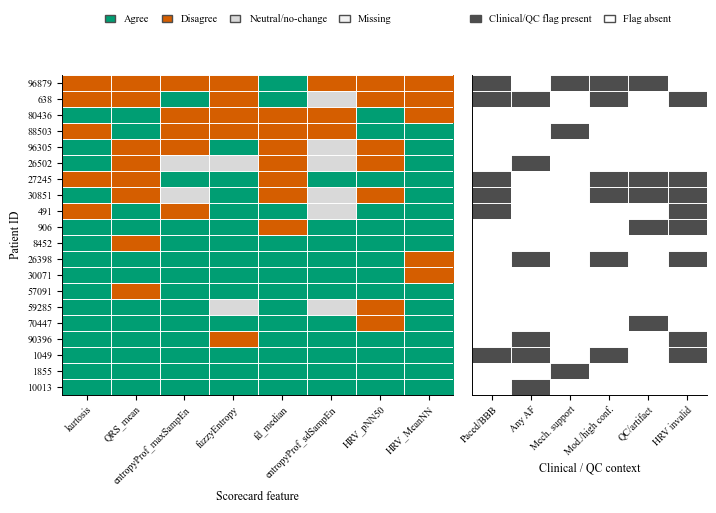

In [21]:
# ============================================================
# Figure: Patient-feature agreement heatmap with clinical context
# Revised version:
# - fd_minimum removed from main heatmap
# - no patient-specific annotation
# - patients ordered by disagreement burden across plotted features
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
# Assumes your earlier notebook already defined:
#   PROJECT_ROOT
#   TABLE_DIR
#   FIGURE_DIR

patient_feature_delta_path = PROJECT_ROOT / "outputs" / "patient_level" / "patient_feature_delta_table_all_features.csv"
final_candidate_scorecard_path = PROJECT_ROOT / "outputs" / "candidate_scorecard" / "final_candidate_scorecard.csv"

# If working directly from /mnt/data, use:
# patient_feature_delta_path = Path("/mnt/data/patient_feature_delta_table_all_features.csv")
# final_candidate_scorecard_path = Path("/mnt/data/final_candidate_scorecard.csv")


# ------------------------------------------------------------
# 2. Read data
# ------------------------------------------------------------

delta = pd.read_csv(patient_feature_delta_path)
scorecard = pd.read_csv(final_candidate_scorecard_path)

delta["Patient_id"] = (
    delta["Patient_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

scorecard["feature"] = scorecard["feature"].astype(str)


# ------------------------------------------------------------
# 3. Candidate feature order and display labels
# ------------------------------------------------------------
# fd_minimum is omitted from the main figure because it is
# exploratory/downgraded and has a no-change cohort-dominant direction.

candidate_feature_order = [
    "kurtosis",
    "QRS_mean",
    "entropyProfiled_maximum_sampleEntropy",
    "fuzzyEntropy",
    "fd_median",
    "entropyProfiled_standardDeviation_sampleEntropy",
    "HRV_pNN50",
    "HRV_MeanNN",
]

feature_display_labels = {
    "kurtosis": "kurtosis",
    "QRS_mean": "QRS_mean",
    "entropyProfiled_maximum_sampleEntropy": "entropyProf_maxSampEn",
    "fuzzyEntropy": "fuzzyEntropy",
    "fd_median": "fd_median",
    "entropyProfiled_standardDeviation_sampleEntropy": "entropyProf_sdSampEn",
    "HRV_pNN50": "HRV_pNN50",
    "HRV_MeanNN": "HRV_MeanNN",
}

available_features = [
    f for f in candidate_feature_order
    if f in set(delta["feature"].astype(str)) and f in set(scorecard["feature"].astype(str))
]

missing_features = sorted(set(candidate_feature_order) - set(available_features))
if missing_features:
    print("Warning: these candidate features were not found and will be omitted:")
    for f in missing_features:
        print(" -", f)


# ------------------------------------------------------------
# 4. Build cohort-direction lookup
# ------------------------------------------------------------

scorecard_sub = scorecard[scorecard["feature"].isin(available_features)].copy()

direction_lookup = (
    scorecard_sub
    .set_index("feature")["dominant_direction"]
    .to_dict()
)

bad_direction_features = [
    f for f in available_features
    if direction_lookup.get(f) not in ["increase", "decrease", "no_change"]
]

if bad_direction_features:
    print("Warning: unexpected cohort directions:")
    for f in bad_direction_features:
        print(f, "->", direction_lookup.get(f))


# ------------------------------------------------------------
# 5. Compute patient-feature agreement status
# ------------------------------------------------------------

plot_df = delta[
    (delta["feature"].isin(available_features)) &
    (delta["paired_observation_available"] == 1)
].copy()

plot_df["cohort_dominant_direction"] = plot_df["feature"].map(direction_lookup)

def agreement_status(row):
    observed = row["observed_direction"]
    cohort = row["cohort_dominant_direction"]

    if pd.isna(observed) or observed == "missing":
        return "missing"

    if observed == "no_change":
        return "neutral_no_change"

    if cohort == "no_change":
        return "agree" if observed == "no_change" else "disagree"

    if observed == cohort:
        return "agree"

    if observed in ["increase", "decrease"] and cohort in ["increase", "decrease"]:
        return "disagree"

    return "missing"

plot_df["agreement_status"] = plot_df.apply(agreement_status, axis=1)

status_to_code = {
    "missing": 0,
    "neutral_no_change": 1,
    "agree": 2,
    "disagree": 3,
}

plot_df["agreement_code"] = (
    plot_df["agreement_status"]
    .map(status_to_code)
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 6. Patient ordering
# ------------------------------------------------------------
# Patients are ordered by disagreement burden across the plotted features:
# first by disagreement proportion, then by disagreement count.

patient_order_df = (
    plot_df
    .groupby("Patient_id")["agreement_status"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["agree", "disagree", "neutral_no_change", "missing"]:
    if col not in patient_order_df.columns:
        patient_order_df[col] = 0

patient_order_df["n_features_available"] = (
    patient_order_df["agree"]
    + patient_order_df["disagree"]
    + patient_order_df["neutral_no_change"]
)

patient_order_df["prop_disagree"] = (
    patient_order_df["disagree"]
    / patient_order_df["n_features_available"].replace(0, np.nan)
)

patient_order_df["Patient_id_numeric"] = pd.to_numeric(
    patient_order_df["Patient_id"],
    errors="coerce"
)

patient_order_df = patient_order_df.sort_values(
    ["prop_disagree", "disagree", "Patient_id_numeric"],
    ascending=[False, False, True],
)

patient_order = patient_order_df["Patient_id"].tolist()


# ------------------------------------------------------------
# 7. Build heatmap matrix
# ------------------------------------------------------------

matrix = (
    plot_df
    .pivot(index="Patient_id", columns="feature", values="agreement_code")
    .reindex(index=patient_order, columns=available_features)
    .fillna(0)
    .astype(int)
)

matrix_out = matrix.copy()
matrix_out.columns = [feature_display_labels.get(c, c) for c in matrix_out.columns]
matrix_out.to_csv(TABLE_DIR / "figure_patient_feature_agreement_heatmap_matrix.csv")


# ------------------------------------------------------------
# 8. Build compact clinical-context annotation matrix
# ------------------------------------------------------------

clinical_flag_groups = {
    "Paced/BBB": ["paced_or_bbb"],
    "Any AF": ["any_af"],
    "Mech. support": ["mechanical_support"],
    "Mod./high conf.": ["moderate_or_high_confound"],
    "QC/artifact": ["known_patient_qc_caution_flag", "known_artifact_patient_flag"],
    "HRV invalid": ["hrv_invalid_flag", "exclude_from_HRV_valid_subgroup"],
}

patient_flags = (
    delta
    .drop_duplicates(subset=["Patient_id"])
    .set_index("Patient_id")
)

clinical_matrix = pd.DataFrame(index=patient_order)

for label, cols in clinical_flag_groups.items():
    available_cols = [c for c in cols if c in patient_flags.columns]

    if len(available_cols) == 0:
        clinical_matrix[label] = 0
    else:
        clinical_matrix[label] = (
            patient_flags
            .reindex(patient_order)[available_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(int)
            .max(axis=1)
        )

clinical_matrix = clinical_matrix.fillna(0).astype(int)
clinical_matrix.to_csv(TABLE_DIR / "figure_patient_feature_agreement_clinical_context_matrix.csv")


# ------------------------------------------------------------
# 9. Plot style
# ------------------------------------------------------------

IEEE_STYLE = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
}
plt.rcParams.update(IEEE_STYLE)

FIG_DPI = 600  # match Figures 1 and 2, not 300

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 7.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

agreement_cmap = ListedColormap([
    "#F2F2F2",  # missing
    "#D9D9D9",  # neutral/no-change
    "#009E73",  # agree
    "#D55E00",  # disagree
])

agreement_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], agreement_cmap.N)

clinical_cmap = ListedColormap([
    "#FFFFFF",  # absent
    "#4D4D4D",  # present
])

clinical_norm = BoundaryNorm([-0.5, 0.5, 1.5], clinical_cmap.N)


# ------------------------------------------------------------
# 10. Create figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(7.16, 5.0), constrained_layout=False)

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[8.0, 4.8],
    wspace=0.06,
)

ax_main = fig.add_subplot(gs[0, 0])
ax_flags = fig.add_subplot(gs[0, 1], sharey=ax_main)

ax_main.imshow(
    matrix.values,
    aspect="auto",
    interpolation="none",
    cmap=agreement_cmap,
    norm=agreement_norm,
)

ax_flags.imshow(
    clinical_matrix.values,
    aspect="auto",
    interpolation="none",
    cmap=clinical_cmap,
    norm=clinical_norm,
)


# ------------------------------------------------------------
# 11. Main heatmap formatting
# ------------------------------------------------------------

ax_main.set_xticks(np.arange(len(available_features)))
ax_main.set_xticklabels(
    [feature_display_labels.get(f, f) for f in available_features],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

ax_main.set_yticks(np.arange(len(patient_order)))
ax_main.set_yticklabels(patient_order)

ax_main.set_ylabel("Patient ID")
ax_main.set_xlabel("Scorecard feature")

ax_main.set_xticks(np.arange(-0.5, len(available_features), 1), minor=True)
ax_main.set_yticks(np.arange(-0.5, len(patient_order), 1), minor=True)
ax_main.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
ax_main.tick_params(which="minor", bottom=False, left=False)

ax_main.set_ylim(len(patient_order) - 0.5, -0.5)


# ------------------------------------------------------------
# 12. Clinical strip formatting
# ------------------------------------------------------------

clinical_labels = clinical_matrix.columns.tolist()

ax_flags.set_xticks(np.arange(len(clinical_labels)))
ax_flags.set_xticklabels(
    clinical_labels,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)

ax_flags.tick_params(axis="y", left=False, labelleft=False)
ax_flags.set_xlabel("Clinical / QC context")

ax_flags.set_xticks(np.arange(-0.5, len(clinical_labels), 1), minor=True)
ax_flags.set_yticks(np.arange(-0.5, len(patient_order), 1), minor=True)
ax_flags.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
ax_flags.tick_params(which="minor", bottom=False, left=False)

ax_flags.set_ylim(len(patient_order) - 0.5, -0.5)


# ------------------------------------------------------------
# 13. Clean spines
# ------------------------------------------------------------

for ax in [ax_main, ax_flags]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.7)
    ax.spines["left"].set_linewidth(0.7)


# ------------------------------------------------------------
# 14. Legends
# ------------------------------------------------------------

agreement_handles = [
    Patch(facecolor="#009E73", edgecolor="0.3", label="Agree"),
    Patch(facecolor="#D55E00", edgecolor="0.3", label="Disagree"),
    Patch(facecolor="#D9D9D9", edgecolor="0.3", label="Neutral/no-change"),
    Patch(facecolor="#F2F2F2", edgecolor="0.3", label="Missing"),
]

clinical_handles = [
    Patch(facecolor="#4D4D4D", edgecolor="0.3", label="Clinical/QC flag present"),
    Patch(facecolor="#FFFFFF", edgecolor="0.3", label="Flag absent"),
]

fig.legend(
    handles=agreement_handles,
    loc="upper center",
    bbox_to_anchor=(0.34, 1.02),
    ncol=4,
    frameon=False,
    handlelength=1.0,
    columnspacing=1.2,
)

fig.legend(
    handles=clinical_handles,
    loc="upper center",
    bbox_to_anchor=(0.79, 1.02),
    ncol=2,
    frameon=False,
    handlelength=1.0,
    columnspacing=1.2,
)

fig.subplots_adjust(
    top=0.88,
    bottom=0.24,
    left=0.08,
    right=0.98,
)


# ------------------------------------------------------------
# 15. Save figure
# ------------------------------------------------------------

pdf_path = FIGURE_DIR / "figure_patient_feature_agreement_heatmap.pdf"
png_path = FIGURE_DIR / "figure_patient_feature_agreement_heatmap.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()